In [1]:
import os, glob
from io import BytesIO

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from PIL import Image

import nugraph as ng

try:
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
except Exception as e:
    EventAccumulator = None
    print("TensorBoard EventAccumulator import failed:", e)

torch.set_float32_matmul_precision("medium")

DATA_PATH = "/home/apaudel/NuGraph/scripts/merged1_Aug6_40k_pmtpmt_g4lepdir_with_vpred_nexusonly"
RUN_NAME = "merged1_Aug24_40k_g4lepdir_tpc_pds_directiononly_axisloss_fixedvpred_nexusfeat_pmtpmt_ep100_bs64_in8_sp5"
RUN_DIR = f"/home/apaudel/NuGraph/logs/{RUN_NAME}"

ckpts = glob.glob(f"{RUN_DIR}/**/*.ckpt", recursive=True)
assert ckpts, f"No checkpoint found under {RUN_DIR}"

CKPT = max(ckpts, key=os.path.getmtime)
VERSION_DIR = os.path.dirname(os.path.dirname(CKPT))

event_files = sorted(glob.glob(f"{VERSION_DIR}/events.out.tfevents.*"))
if not event_files:
    event_files = sorted(glob.glob(f"{RUN_DIR}/**/events.out.tfevents.*", recursive=True))

print("DATA_PATH   =", DATA_PATH)
print("RUN_NAME    =", RUN_NAME)
print("RUN_DIR     =", RUN_DIR)
print("VERSION_DIR =", VERSION_DIR)
print("CKPT        =", CKPT)
print("event files =", len(event_files))
for f in event_files:
    print(" ", f)

raw = torch.load(CKPT, map_location="cpu")
hp = raw.get("hyper_parameters", {})

print("\nCheckpoint hparams:")
for k in [
    "semantic_head", "vertex_head", "direction_head", "event_head",
    "sp_features", "use_optical", "use_pmt_pmt"
]:
    print(f"{k:16s} =", hp.get(k, "MISSING"))

Data = ng.data.H5DataModule
Model = ng.models.NuGraph3

nudata = Data(
    DATA_PATH,
    batch_size=64,
    num_workers=0,
    model=Model,
    shuffle="random",
    featext3d=True,
)

model = Model.load_from_checkpoint(CKPT)
model.eval()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("\nDataset lengths:")
print("train =", len(nudata.train_dataset))
print("val   =", len(nudata.val_dataset))
print("test  =", len(nudata.test_dataset))

print("\nModel sanity:")
print("use_optical =", model.use_optical)
print("PMT-PMT active =", model.optical_net.use_pmt_pmt if hasattr(model, "optical_net") else None)
print("sp_net active =", model.encoder.sp_net is not None)
print("has direction_decoder =", hasattr(model, "direction_decoder"))
print("has vertex_decoder =", hasattr(model, "vertex_decoder"))

DATA_PATH   = /home/apaudel/NuGraph/scripts/merged1_Aug6_40k_pmtpmt_g4lepdir_with_vpred_nexusonly
RUN_NAME    = merged1_Aug24_40k_g4lepdir_tpc_pds_directiononly_axisloss_fixedvpred_nexusfeat_pmtpmt_ep100_bs64_in8_sp5
RUN_DIR     = /home/apaudel/NuGraph/logs/merged1_Aug24_40k_g4lepdir_tpc_pds_directiononly_axisloss_fixedvpred_nexusfeat_pmtpmt_ep100_bs64_in8_sp5
VERSION_DIR = /home/apaudel/NuGraph/logs/merged1_Aug24_40k_g4lepdir_tpc_pds_directiononly_axisloss_fixedvpred_nexusfeat_pmtpmt_ep100_bs64_in8_sp5/version_0
CKPT        = /home/apaudel/NuGraph/logs/merged1_Aug24_40k_g4lepdir_tpc_pds_directiononly_axisloss_fixedvpred_nexusfeat_pmtpmt_ep100_bs64_in8_sp5/version_0/checkpoints/epoch=99-step=47000.ckpt
event files = 1
  /home/apaudel/NuGraph/logs/merged1_Aug24_40k_g4lepdir_tpc_pds_directiononly_axisloss_fixedvpred_nexusfeat_pmtpmt_ep100_bs64_in8_sp5/version_0/events.out.tfevents.1787577068.jupyter-apaudel.6327.0

Checkpoint hparams:
semantic_head    = False
vertex_head      = False
dir

========== TensorBoard logs ==========
Reading TensorBoard logs from: /home/apaudel/NuGraph/logs/merged1_Aug24_40k_g4lepdir_tpc_pds_directiononly_axisloss_fixedvpred_nexusfeat_pmtpmt_ep100_bs64_in8_sp5/version_0

Number of scalar tags: 40
Number of image tags: 0

Scalar tags containing loss/cos/angle/resolution/ux/uy/uz/direction:
  direction/angle-deg-median-train
  direction/angle-deg-median-val
  direction/angle-deg-train
  direction/angle-deg-val
  direction/attention-max-weight-train
  direction/attention-max-weight-val
  direction/axis-angle-deg-median-train
  direction/axis-angle-deg-median-val
  direction/axis-angle-deg-train
  direction/axis-angle-deg-val
  direction/axis-cosine-train
  direction/axis-cosine-val
  direction/axis-ux-resolution-train
  direction/axis-ux-resolution-val
  direction/axis-uy-resolution-train
  direction/axis-uy-resolution-val
  direction/axis-uz-resolution-train
  direction/axis-uz-resolution-val
  direction/cosine-train
  direction/cosine-val
  dir

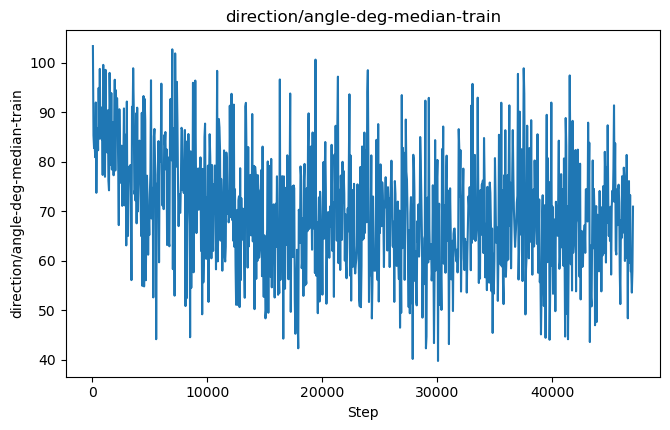

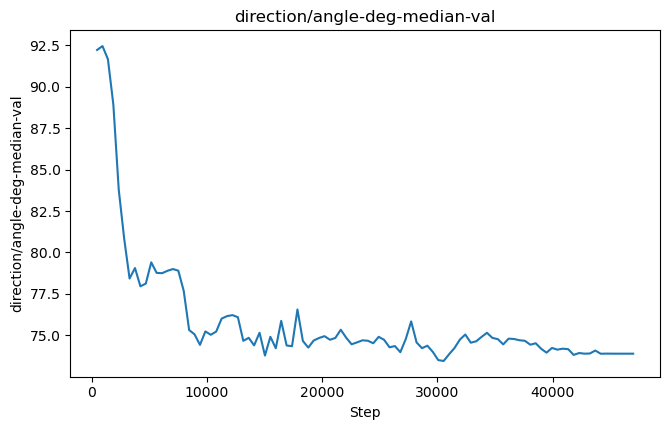

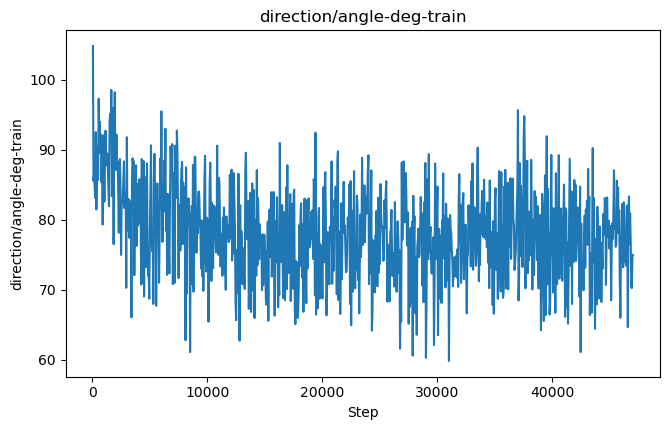

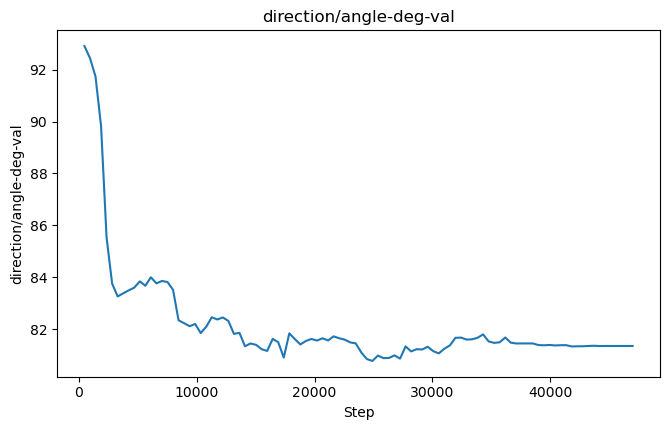

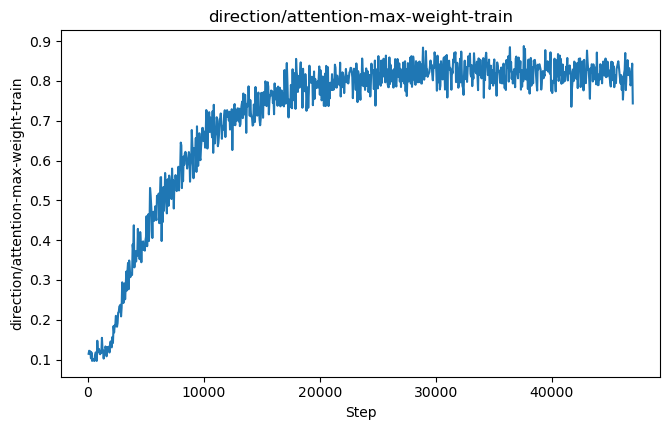

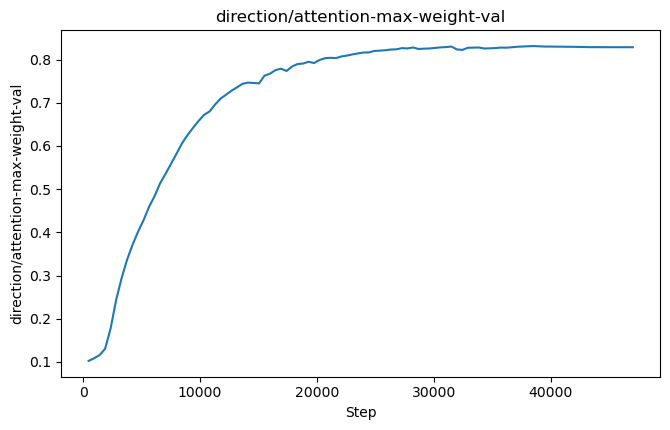

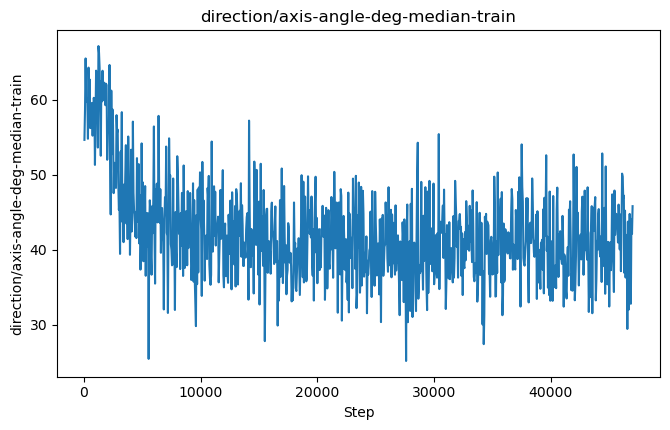

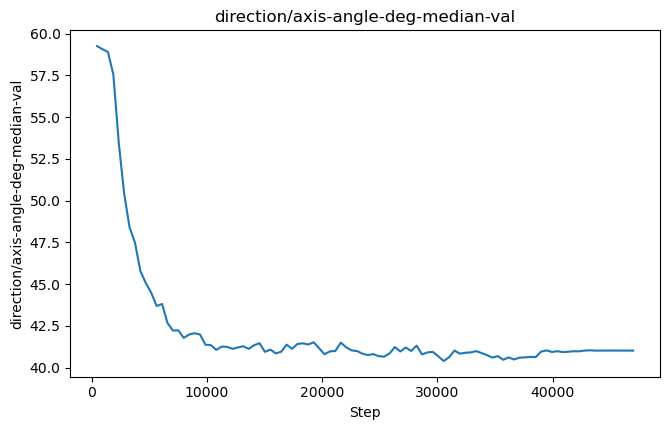

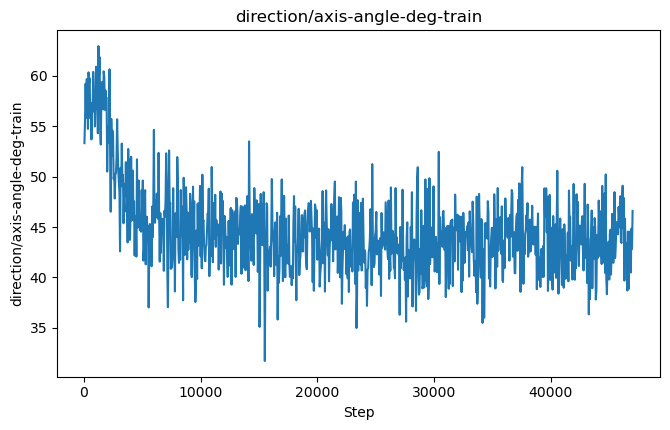

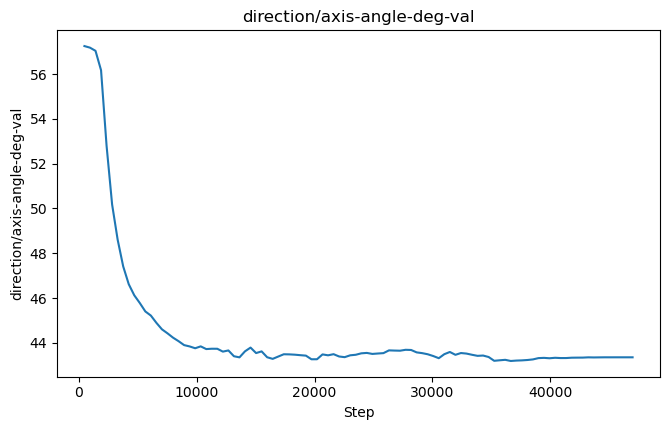

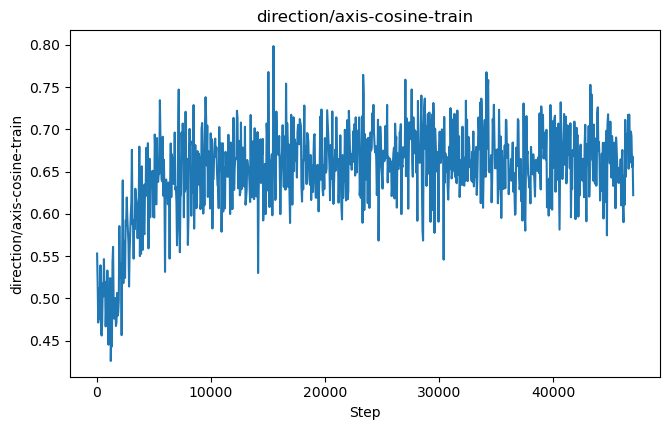

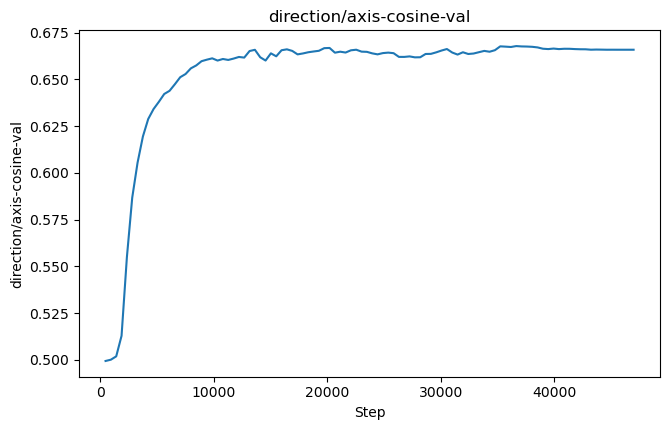

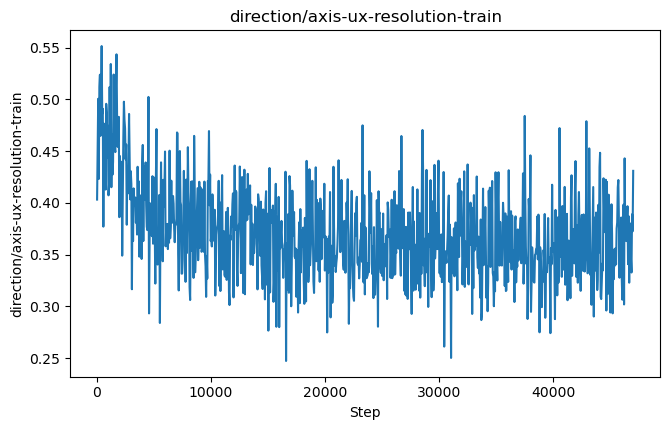

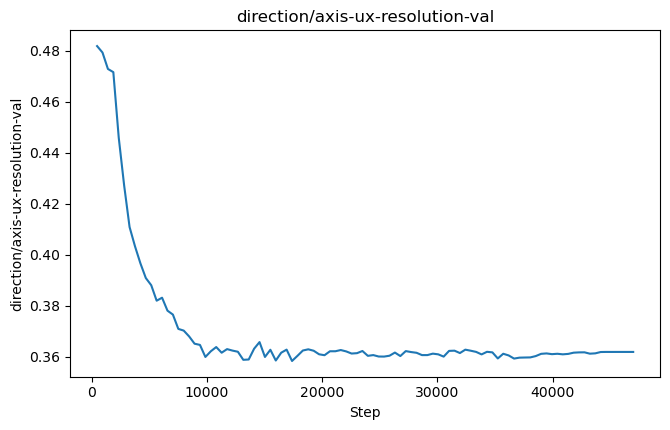

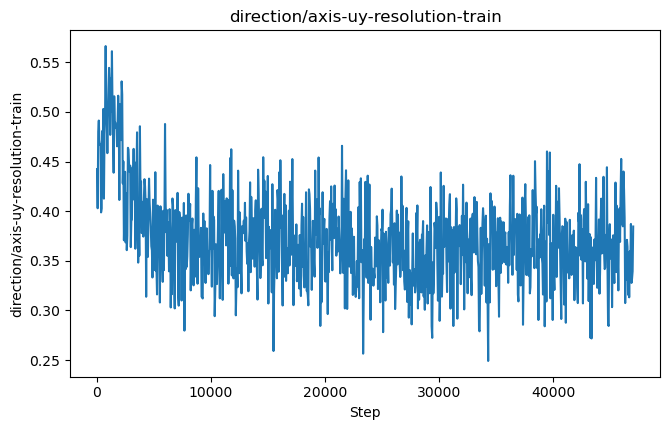

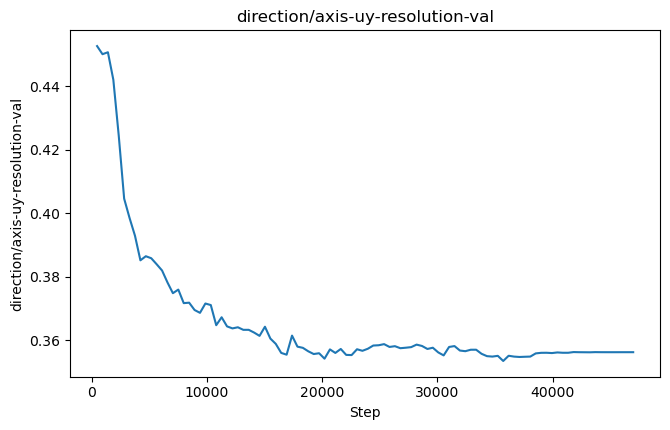

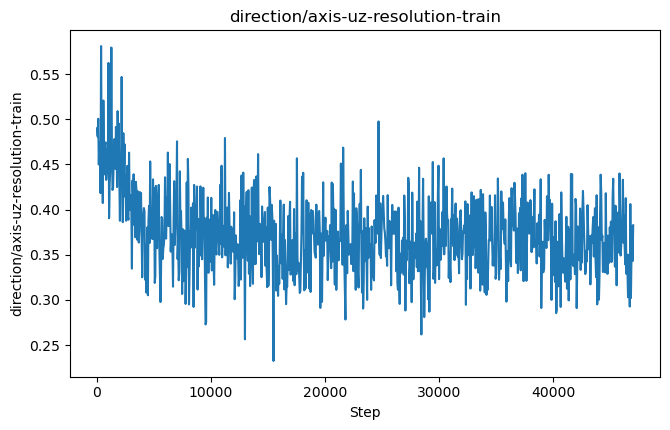

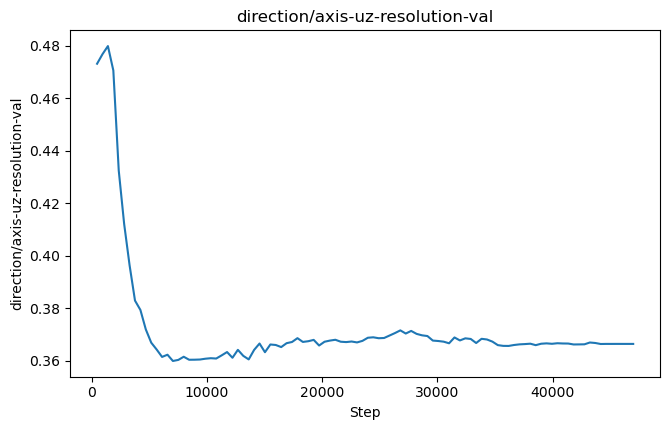

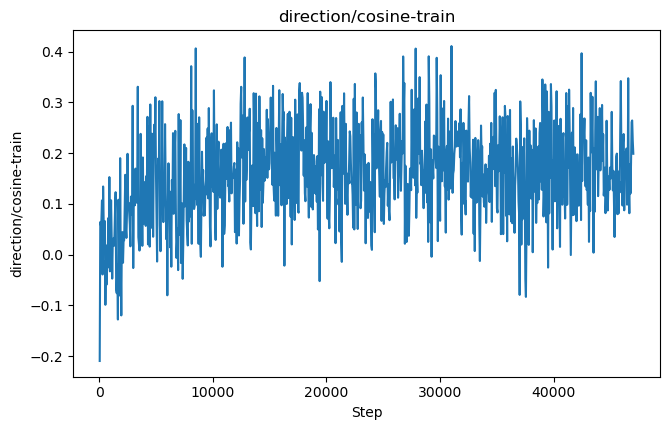

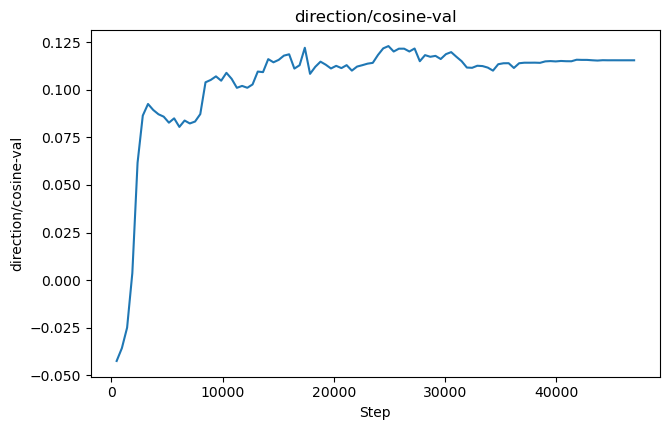

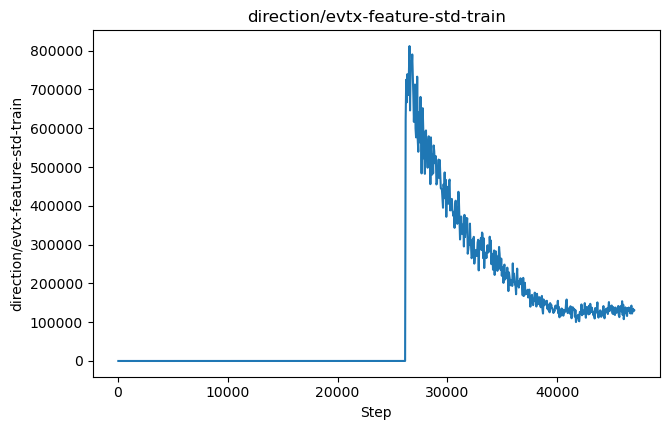

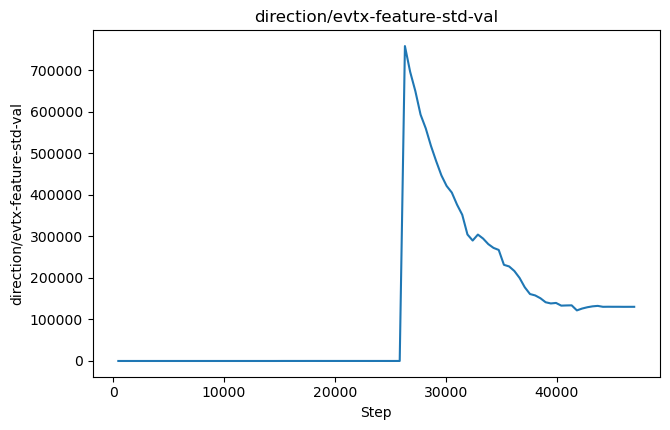

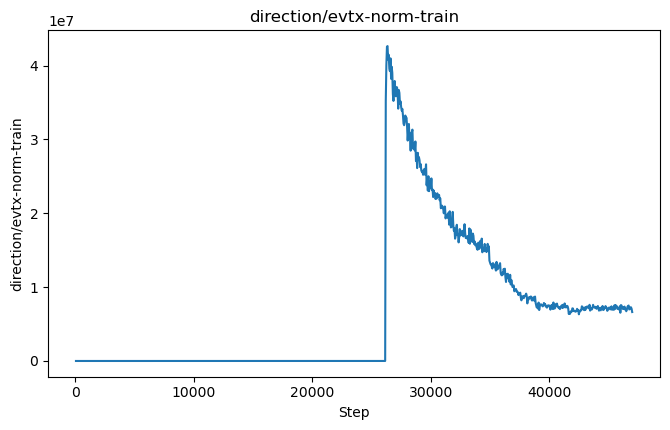

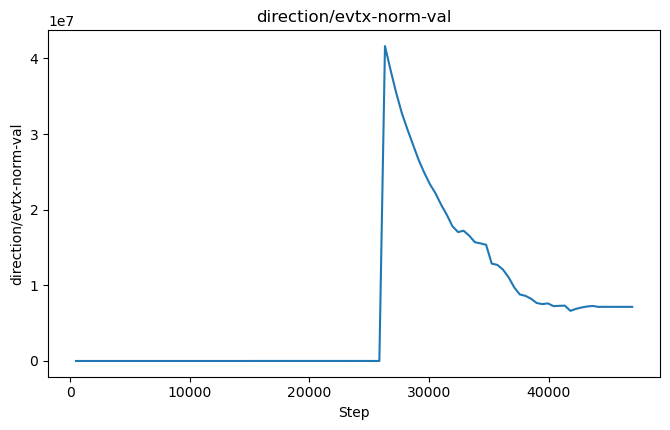

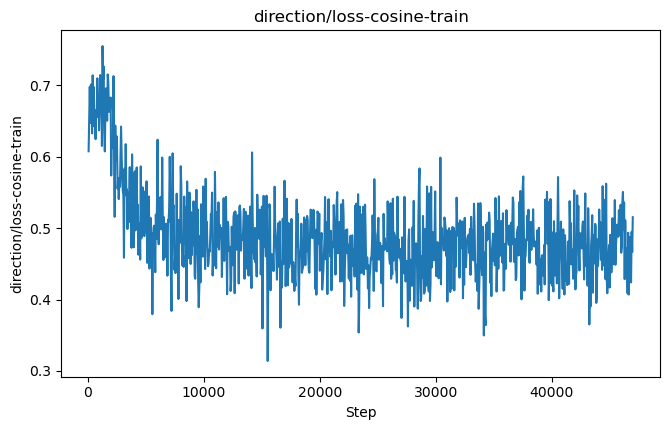

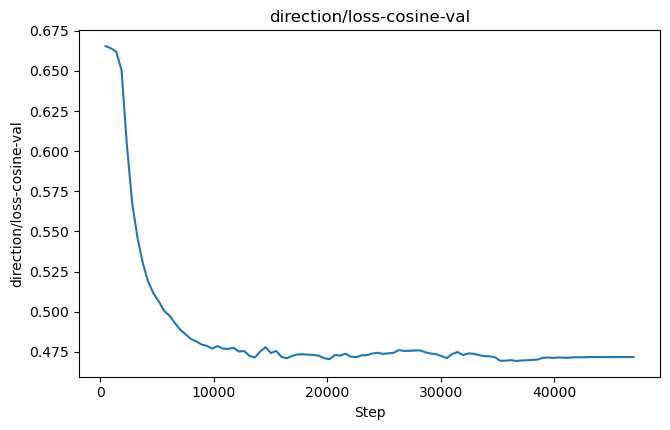

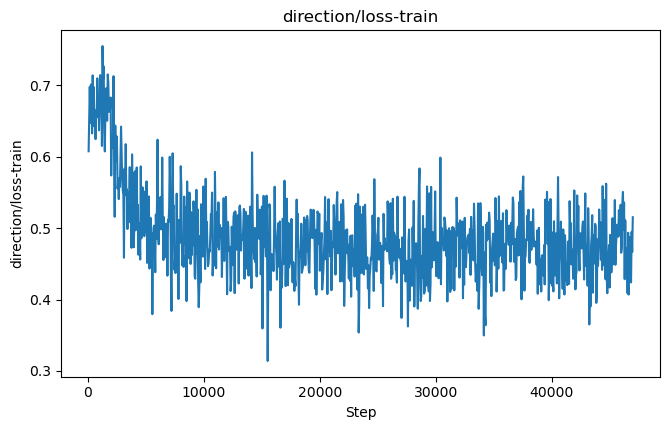

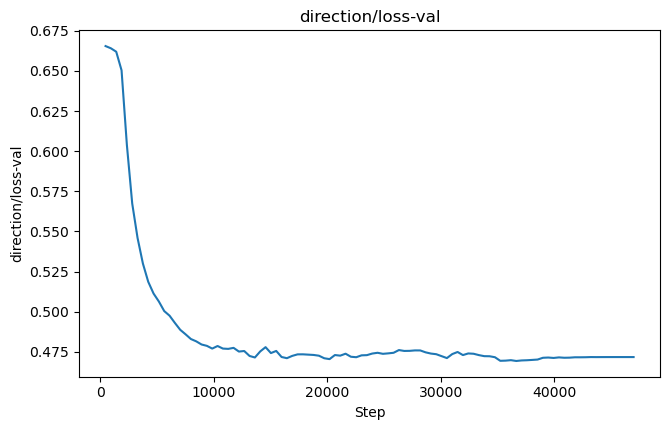

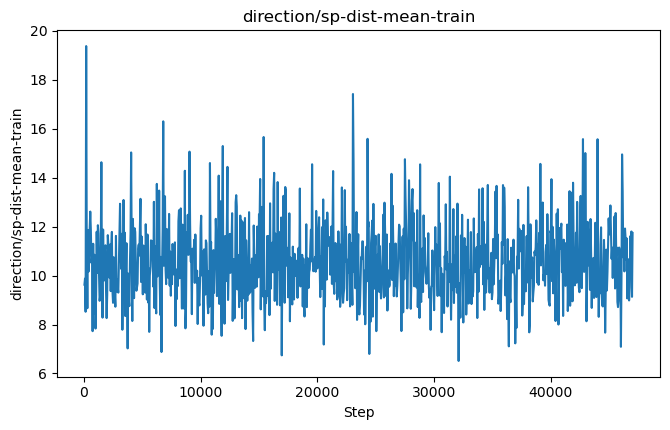

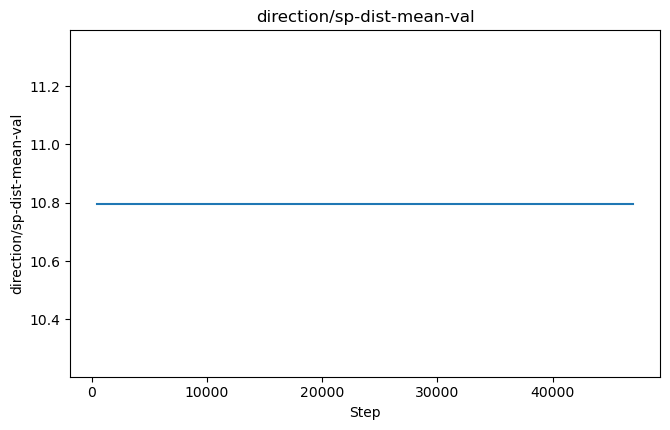

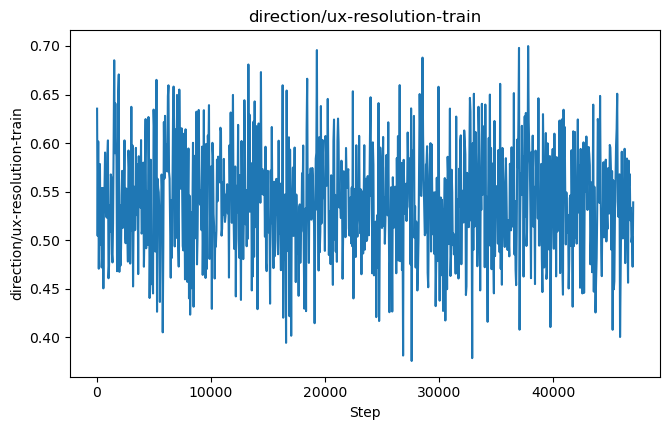

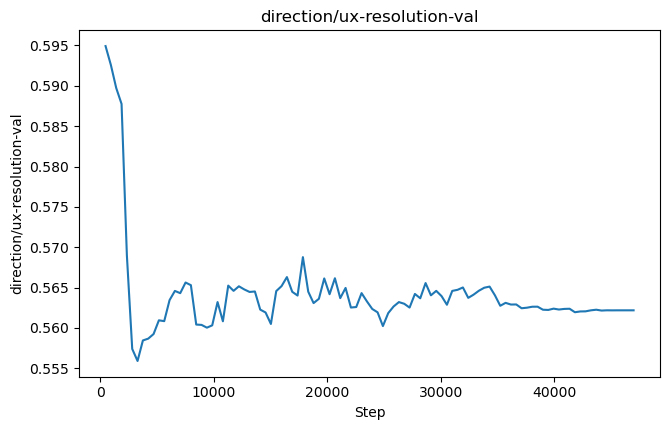

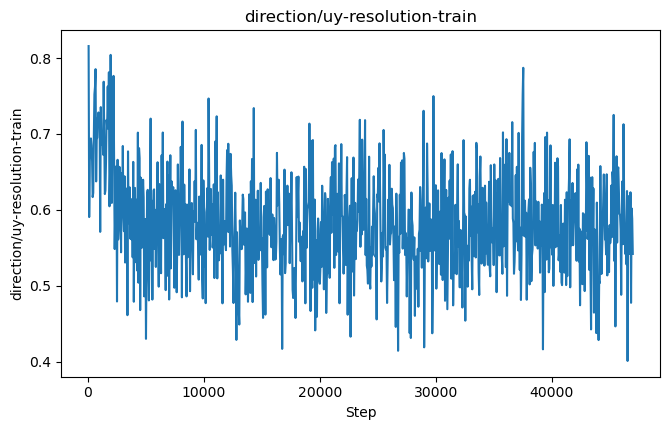

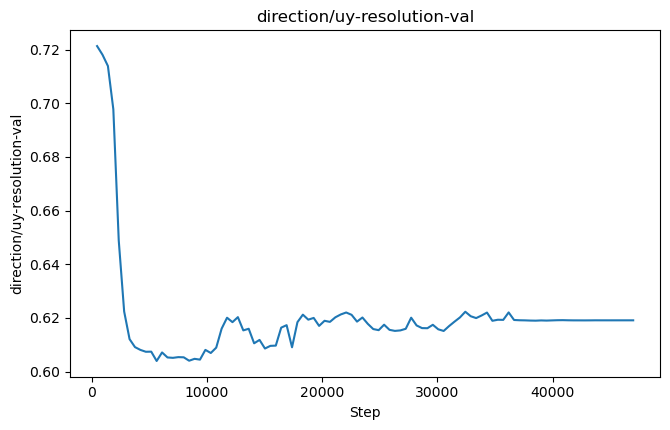

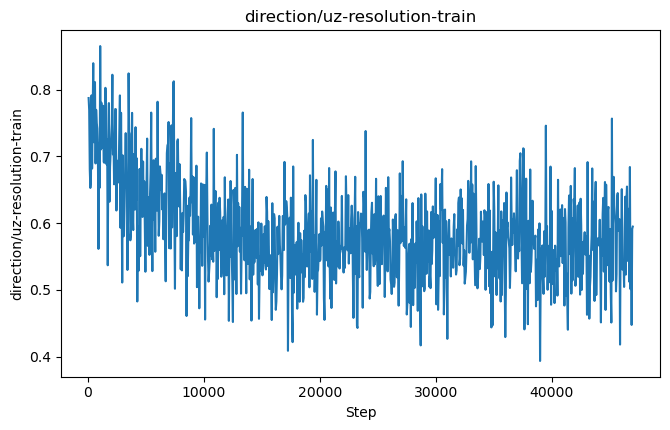

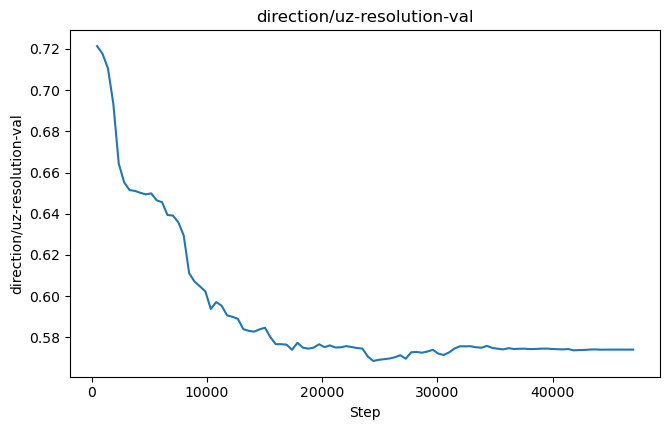

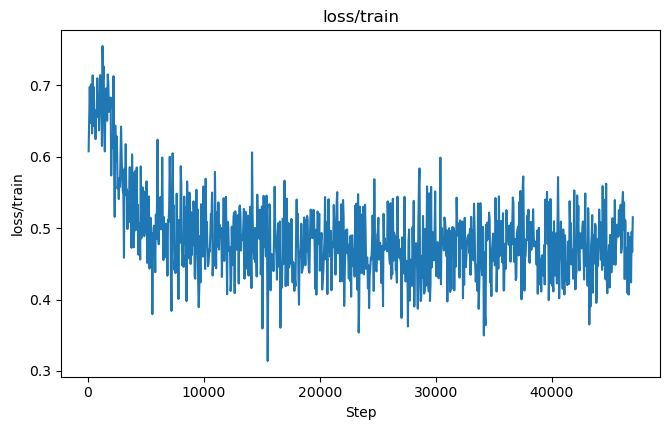

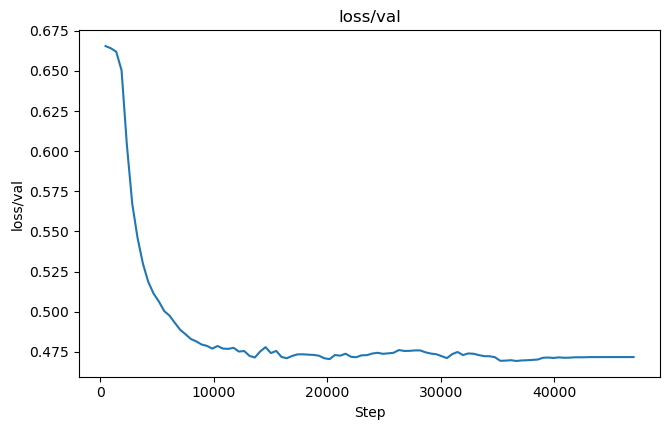

,N test,median axis angle deg,mean axis angle deg,p68 axis angle deg,p90 axis angle deg,median |cos axis|,mean |cos axis|,frac axis angle < 10 deg,frac axis angle < 20 deg,frac axis angle < 30 deg,median |Δux|,median |Δuy|,median |Δuz|,mean |Δux|,mean |Δuy|,mean |Δuz|,stored evt.v_pred median err cm,stored evt.v_pred mean err cm,stored evt.v_pred p68 err cm,stored evt.v_pred p90 err cm
0,1672,42.1152,43.974998,56.817299,79.442299,0.7418,0.6595,0.0622,0.201,0.3415,0.283,0.2694,0.2965,0.3669,0.3606,0.3698,5.4797,8.3818,8.1207,17.76



Median angle between true and predicted AXIS:
  median axis angle = 42.12 deg
  mean axis angle   = 43.98 deg
  p68 axis angle    = 56.82 deg
  p90 axis angle    = 79.44 deg

Stored vertex sanity:
  stored evt.v_pred median residual = 5.48 cm
  stored evt.v_pred p68 residual    = 8.12 cm
  stored evt.v_pred p90 residual    = 17.76 cm


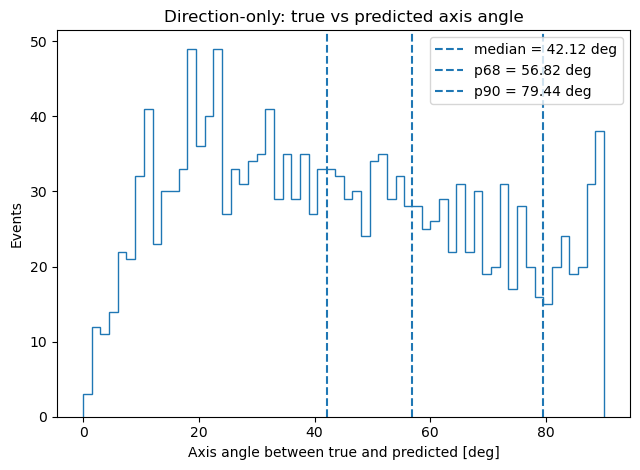

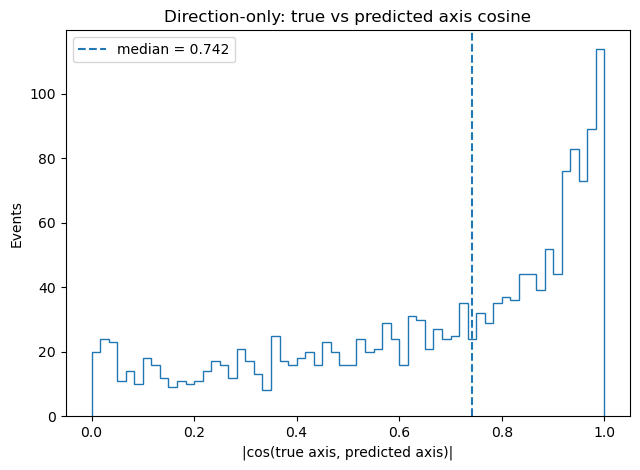

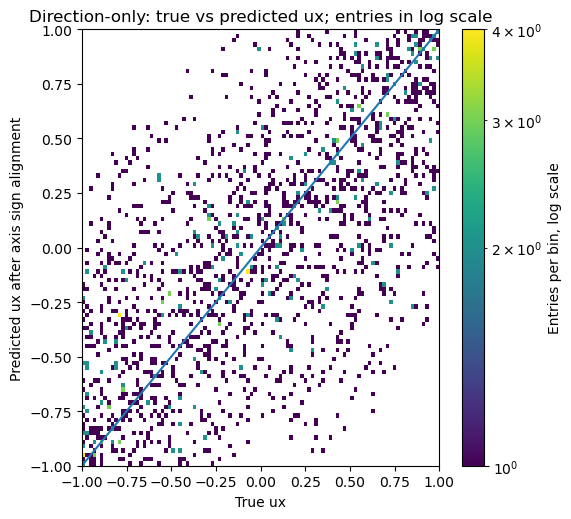

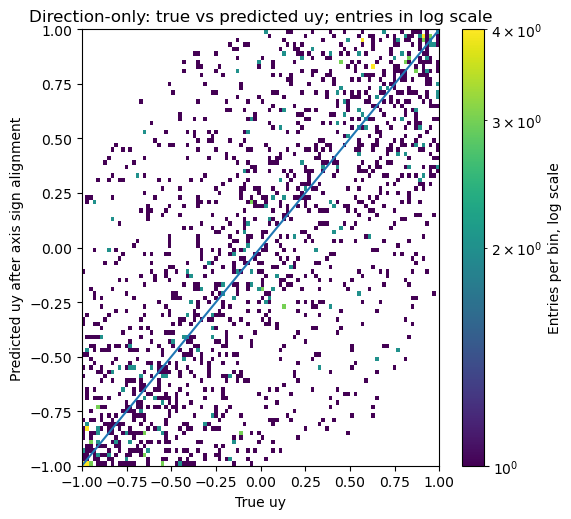

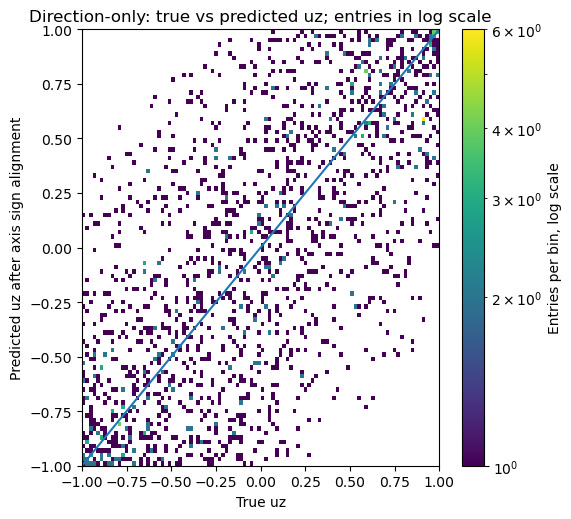

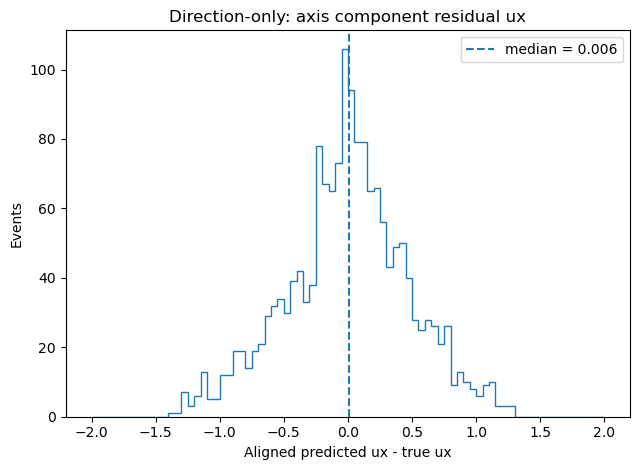

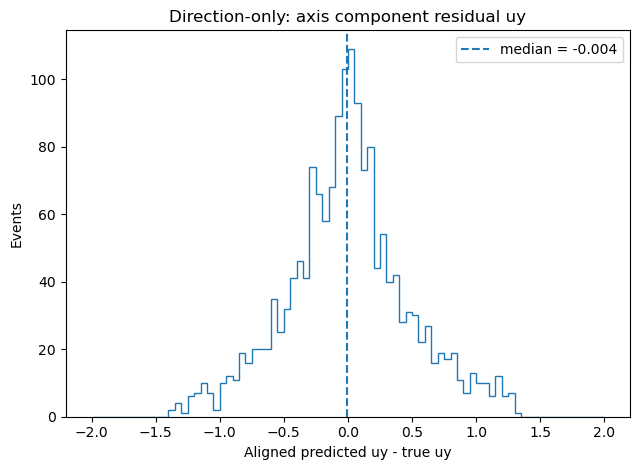

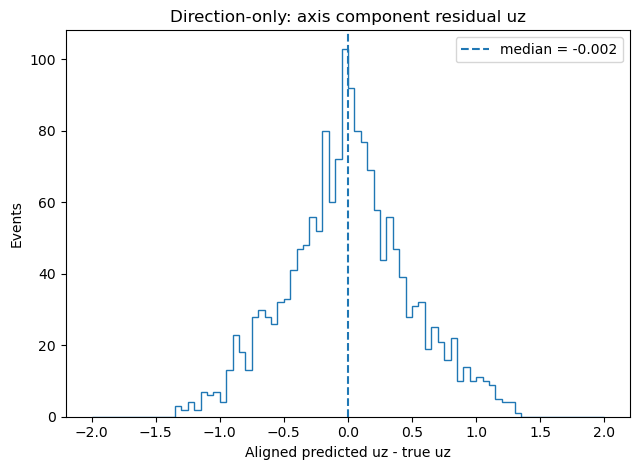

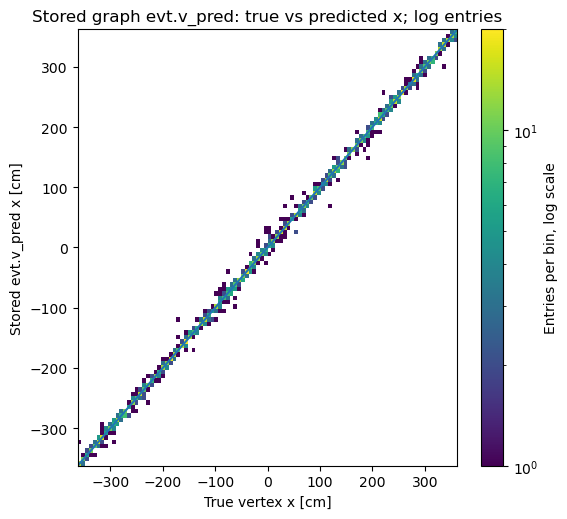

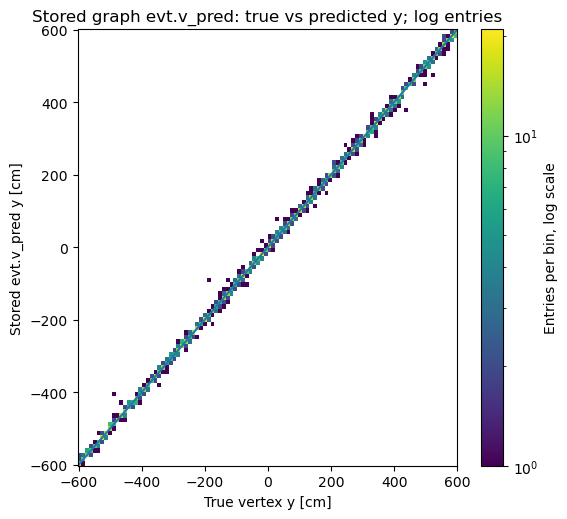

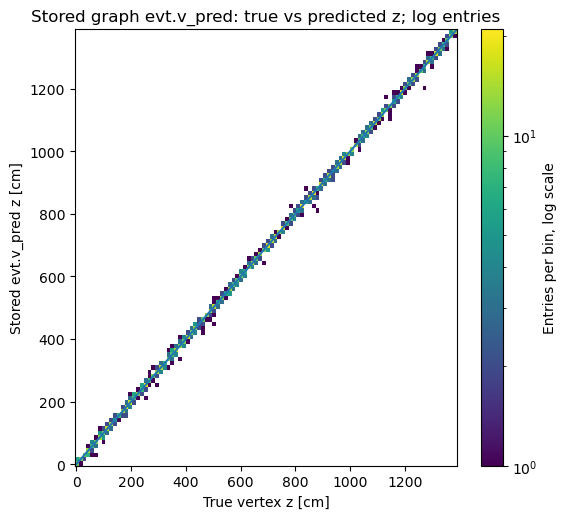

In [2]:
# ============================================================
# 0. Show TensorBoard scalar/image logs for this run
# ============================================================

print("========== TensorBoard logs ==========")

if EventAccumulator is not None and event_files:
    # Prefer event files from the same version as the checkpoint.
    acc_dir = VERSION_DIR if glob.glob(f"{VERSION_DIR}/events.out.tfevents.*") else RUN_DIR

    print("Reading TensorBoard logs from:", acc_dir)

    acc = EventAccumulator(acc_dir, size_guidance={"scalars": 0, "images": 0})
    acc.Reload()

    scalar_tags = sorted(acc.Tags().get("scalars", []))
    image_tags = sorted(acc.Tags().get("images", []))

    print("\nNumber of scalar tags:", len(scalar_tags))
    print("Number of image tags:", len(image_tags))

    important_tags = [
        t for t in scalar_tags
        if any(s in t.lower() for s in [
            "loss",
            "cos",
            "angle",
            "resolution",
            "ux",
            "uy",
            "uz",
            "direction",
        ])
    ]

    print("\nScalar tags containing loss/cos/angle/resolution/ux/uy/uz/direction:")
    for t in important_tags:
        print(" ", t)

    print("\nImage tags:")
    for t in image_tags:
        print(" ", t)

    # Plot important scalar curves one by one.
    for tag in important_tags:
        evs = acc.Scalars(tag)
        steps = np.array([e.step for e in evs])
        vals = np.array([e.value for e in evs])

        plt.figure(figsize=(6.8, 4.4))
        plt.plot(steps, vals)
        plt.xlabel("Step")
        plt.ylabel(tag)
        plt.title(tag)
        plt.tight_layout()
        plt.show()

    # Show logged TensorBoard images, if any.
    for tag in image_tags:
        imgs = acc.Images(tag)
        for i, im in enumerate(imgs):
            img = Image.open(BytesIO(im.encoded_image_string))
            plt.figure(figsize=(8, 6))
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"{tag}, step={im.step}, index={i}")
            plt.tight_layout()
            plt.show()
else:
    print("No readable TensorBoard event files.")


# ============================================================
# 1. Evaluate model on test set
# ============================================================

rows = []

with torch.no_grad():
    for batch in nudata.test_dataloader():
        batch = batch.to(device)

        # Direction-only model fills evt.d.
        model(batch, "test")

        evt = batch["evt"]

        rows.append({
            "true_dir": evt.y_dir.detach().float().cpu().numpy(),
            "pred_dir": evt.d.detach().float().cpu().numpy(),

            # stored fixed vertex used by direction decoder
            "true_vtx": evt.y_vtx.detach().float().cpu().numpy(),
            "stored_vpred": evt.v_pred.detach().float().cpu().numpy(),
        })

true_dir = np.concatenate([r["true_dir"] for r in rows], axis=0)
pred_dir = np.concatenate([r["pred_dir"] for r in rows], axis=0)

true_vtx = np.concatenate([r["true_vtx"] for r in rows], axis=0)
stored_vpred = np.concatenate([r["stored_vpred"] for r in rows], axis=0)

def unit(x):
    n = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.clip(n, 1.0e-12, None)

true_axis = unit(true_dir)
pred_axis = unit(pred_dir)

# Axis-loss comparison:
# u and -u are equivalent, so use abs(dot).
cos_signed = np.sum(true_axis * pred_axis, axis=1)
cos_signed = np.clip(cos_signed, -1.0, 1.0)

axis_cos = np.abs(cos_signed)
axis_angle_deg = np.degrees(np.arccos(axis_cos))

# Global sign alignment for component plots.
# This is the correct axis comparison:
# (ux, uy, uz) equivalent to (-ux, -uy, -uz).
axis_sign = np.where(cos_signed >= 0.0, 1.0, -1.0)[:, None]
pred_axis_aligned = pred_axis * axis_sign

axis_residual_vec = pred_axis_aligned - true_axis
axis_component_abs = np.abs(axis_residual_vec)

stored_vpred_residual = stored_vpred - true_vtx
stored_vpred_err = np.linalg.norm(stored_vpred_residual, axis=1)

# ============================================================
# 2. Summary numbers
# ============================================================

summary = {
    "N test": len(axis_angle_deg),

    "median axis angle deg": np.median(axis_angle_deg),
    "mean axis angle deg": np.mean(axis_angle_deg),
    "p68 axis angle deg": np.percentile(axis_angle_deg, 68),
    "p90 axis angle deg": np.percentile(axis_angle_deg, 90),

    "median |cos axis|": np.median(axis_cos),
    "mean |cos axis|": np.mean(axis_cos),

    "frac axis angle < 10 deg": np.mean(axis_angle_deg < 10),
    "frac axis angle < 20 deg": np.mean(axis_angle_deg < 20),
    "frac axis angle < 30 deg": np.mean(axis_angle_deg < 30),

    "median |Δux|": np.median(axis_component_abs[:, 0]),
    "median |Δuy|": np.median(axis_component_abs[:, 1]),
    "median |Δuz|": np.median(axis_component_abs[:, 2]),

    "mean |Δux|": np.mean(axis_component_abs[:, 0]),
    "mean |Δuy|": np.mean(axis_component_abs[:, 1]),
    "mean |Δuz|": np.mean(axis_component_abs[:, 2]),

    "stored evt.v_pred median err cm": np.median(stored_vpred_err),
    "stored evt.v_pred mean err cm": np.mean(stored_vpred_err),
    "stored evt.v_pred p68 err cm": np.percentile(stored_vpred_err, 68),
    "stored evt.v_pred p90 err cm": np.percentile(stored_vpred_err, 90),
}

display(pd.DataFrame([summary]).round(4))

print("\nMedian angle between true and predicted AXIS:")
print(f"  median axis angle = {np.median(axis_angle_deg):.2f} deg")
print(f"  mean axis angle   = {np.mean(axis_angle_deg):.2f} deg")
print(f"  p68 axis angle    = {np.percentile(axis_angle_deg, 68):.2f} deg")
print(f"  p90 axis angle    = {np.percentile(axis_angle_deg, 90):.2f} deg")

print("\nStored vertex sanity:")
print(f"  stored evt.v_pred median residual = {np.median(stored_vpred_err):.2f} cm")
print(f"  stored evt.v_pred p68 residual    = {np.percentile(stored_vpred_err, 68):.2f} cm")
print(f"  stored evt.v_pred p90 residual    = {np.percentile(stored_vpred_err, 90):.2f} cm")


# ============================================================
# 3. Angle and cosine plots
# ============================================================

plt.figure(figsize=(6.5, 4.8))
plt.hist(axis_angle_deg, bins=60, range=(0, 90), histtype="step")
plt.axvline(np.median(axis_angle_deg), linestyle="--", label=f"median = {np.median(axis_angle_deg):.2f} deg")
plt.axvline(np.percentile(axis_angle_deg, 68), linestyle="--", label=f"p68 = {np.percentile(axis_angle_deg, 68):.2f} deg")
plt.axvline(np.percentile(axis_angle_deg, 90), linestyle="--", label=f"p90 = {np.percentile(axis_angle_deg, 90):.2f} deg")
plt.xlabel("Axis angle between true and predicted [deg]")
plt.ylabel("Events")
plt.title("Direction-only: true vs predicted axis angle")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.5, 4.8))
plt.hist(axis_cos, bins=60, range=(0, 1), histtype="step")
plt.axvline(np.median(axis_cos), linestyle="--", label=f"median = {np.median(axis_cos):.3f}")
plt.xlabel("|cos(true axis, predicted axis)|")
plt.ylabel("Events")
plt.title("Direction-only: true vs predicted axis cosine")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 4. ux, uy, uz true vs predicted
# Linear x/y axes, log-scaled entries/color
# ============================================================

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    plt.figure(figsize=(5.8, 5.3))

    plt.hist2d(
        true_axis[:, coord],
        pred_axis_aligned[:, coord],
        bins=100,
        range=[[-1, 1], [-1, 1]],
        norm=LogNorm(),
    )

    plt.plot([-1, 1], [-1, 1], linewidth=1.5)
    plt.xlabel(f"True u{label}")
    plt.ylabel(f"Predicted u{label} after axis sign alignment")
    plt.title(f"Direction-only: true vs predicted u{label}; entries in log scale")
    cbar = plt.colorbar()
    cbar.set_label("Entries per bin, log scale")
    plt.tight_layout()
    plt.show()


# ============================================================
# 5. Direction component residuals
# ============================================================

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    residual = axis_residual_vec[:, coord]

    plt.figure(figsize=(6.5, 4.8))
    plt.hist(residual, bins=80, range=(-2, 2), histtype="step")
    plt.axvline(np.median(residual), linestyle="--", label=f"median = {np.median(residual):.3f}")
    plt.xlabel(f"Aligned predicted u{label} - true u{label}")
    plt.ylabel("Events")
    plt.title(f"Direction-only: axis component residual u{label}")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 6. Stored v_pred sanity check
# This is not a current model vertex output.
# It checks the fixed vertex stored inside the graph.
# ============================================================

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    lo = min(true_vtx[:, coord].min(), stored_vpred[:, coord].min())
    hi = max(true_vtx[:, coord].max(), stored_vpred[:, coord].max())

    plt.figure(figsize=(5.8, 5.3))

    plt.hist2d(
        true_vtx[:, coord],
        stored_vpred[:, coord],
        bins=100,
        range=[[lo, hi], [lo, hi]],
        norm=LogNorm(),
    )

    plt.plot([lo, hi], [lo, hi], linewidth=1.5)
    plt.xlabel(f"True vertex {label} [cm]")
    plt.ylabel(f"Stored evt.v_pred {label} [cm]")
    plt.title(f"Stored graph evt.v_pred: true vs predicted {label}; log entries")
    cbar = plt.colorbar()
    cbar.set_label("Entries per bin, log scale")
    plt.tight_layout()
    plt.show()